In [1]:
import sys, platform, subprocess, datetime
import torch

print("===== Environment Info =====")
print("OS:", platform.platform())
print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA (torch built with):", torch.version.cuda)
print("cuDNN version:", torch.backends.cudnn.version())

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU compute capability:", torch.cuda.get_device_capability(0))
    print("GPU total memory (GB):", torch.cuda.get_device_properties(0).total_memory / 1e9)

try:
    import transformers
    print("transformers:", transformers.__version__)
except ImportError:
    print("transformers: not installed")

print("\n--- nvidia-smi (driver version included")
print(subprocess.run(["nvidia-smi"], capture_output=True, text=True).stdout)

===== Environment Info =====
OS: Linux-6.6.122+-x86_64-with-glibc2.35
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA (torch built with): 12.8
cuDNN version: 91900
GPU available: True
GPU name: Tesla T4
GPU compute capability: (7, 5)
GPU total memory (GB): 15.637086208
transformers: 5.13.1

--- nvidia-smi (driver version included
Tue Aug 18 01:17:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+===

In [ ]:
%cd "/content/drive/MyDrive/Project/nanoGPT/KV Cache/2_time_estimation_per_token/"

In [3]:
!python one_token_estimation_test_file.py

loading weights from pretrained gpt: gpt2
forcing vocab_size=50257, block_size=1024, bias=True
overriding dropout rate to 0.0
number of parameters: 123.65M
config.json: 100% 665/665 [00:00<00:00, 2.83MB/s]

model.safetensors: downloading bytes:  44% 239M/548M [00:02<00:01, 214MB/s, 21.1MB/s  ]
model.safetensors: downloading bytes:  51% 281M/548M [00:02<00:01, 208MB/s, 23.7MB/s  ]
model.safetensors: downloading bytes:  85% 465M/548M [00:02<00:00, 327MB/s, 37.9MB/s  ]
model.safetensors: reconstructing file:  73% 402M/548M [00:03<00:00, 160MB/s, 25.1MB/s  ]
model.safetensors: downloading bytes: 100% 474M/474M [00:03<00:00, 140MB/s, 42.2MB/s  ]
model.safetensors: reconstructing file: 100% 548M/548M [00:03<00:00, 162MB/s, 48.9MB/s  ]
Loading weights: 100% 148/148 [00:00<00:00, 6661.91it/s]
generation_config.json: 100% 124/124 [00:00<00:00, 565kB/s]
===== running_mode = inf_no_cache =====
[inf_no_cache] step 1014: next tokens = ['\n', 'ide', ' the', ',', ',', ' I', ' your', '?', ' much', ','

In [4]:
# Average time check
import torch

# Define the path to the .pt file
file_path = '/content/drive/MyDrive/Project/nanoGPT/KV Cache/2_time_estimation_per_token/Time_estimation_result/one_token_estimation_result.pt'

# Load the data from the .pt file
try:
    data = torch.load(file_path)
except FileNotFoundError:
    print(f"Error: The file {file_path} was not found.")
    data = None
except Exception as e:
    print(f"An error occurred while loading the file: {e}")
    data = None

if data:
    # Extract the time results
    time_results = data.get('time_result')

    if time_results:
        inf_no_cache_times = time_results.get('inf_no_cache')
        inf_cache_times = time_results.get('inf_cache')

        # Calculate and print average time for each token in inf_no_cache
        if inf_no_cache_times:
            print("\n--- Average time per token for inf_no_cache ---")
            for token_num, times in inf_no_cache_times.items():
                if times and len(times) > 0:
                    avg_time = sum(times) / len(times)
                    print(f"Token {token_num}: {avg_time:.3f} ms")
                else:
                    print(f"Token {token_num}: No times found or list is empty.")
        else:
            print("No 'inf_no_cache' times found.")

        # Calculate and print average time for each token in inf_cache
        if inf_cache_times:
            print("\n--- Average time per token for inf_cache ---")
            for token_num, times in inf_cache_times.items():
                if times and len(times) > 0:
                    avg_time = sum(times) / len(times)
                    print(f"Token {token_num}: {avg_time:.3f} ms")
                else:
                    print(f"Token {token_num}: No times found or list is empty.")
        else:
            print("No 'inf_cache' times found.")
    else:
        print("Key 'time_result' not found in the loaded data.")
else:
    print("Could not process data due to loading error.")


--- Average time per token for inf_no_cache ---
Token 1014: 1893.109 ms
Token 1015: 1891.621 ms
Token 1016: 1882.963 ms
Token 1017: 1897.358 ms
Token 1018: 1896.273 ms
Token 1019: 1898.914 ms
Token 1020: 1896.160 ms
Token 1021: 1907.146 ms
Token 1022: 1908.680 ms
Token 1023: 1920.570 ms

--- Average time per token for inf_cache ---
Token 1014: 1934.404 ms
Token 1015: 40.641 ms
Token 1016: 37.227 ms
Token 1017: 36.213 ms
Token 1018: 36.247 ms
Token 1019: 36.252 ms
Token 1020: 36.045 ms
Token 1021: 36.230 ms
Token 1022: 36.238 ms
Token 1023: 36.379 ms


In [5]:
import numpy as np

# Function to calculate and print statistics
def print_statistics(mode_name, times_data):
    print(f"\n--- Statistics for {mode_name} ---")
    print("Step | Mean        Std         p50         p95         p99         Min         Max")
    print("---------------------------------------------------------------------------------------")

    if times_data:
        for token_num, times in times_data.items():
            if times and len(times) > 0:
                times_np = np.array(times)
                mean_val = np.mean(times_np)
                std_val = np.std(times_np)
                p50_val = np.percentile(times_np, 50)
                p95_val = np.percentile(times_np, 95)
                p99_val = np.percentile(times_np, 99)
                min_val = np.min(times_np)
                max_val = np.max(times_np)
                print(f"{token_num:<4} | {mean_val:<10.3f}  {std_val:<10.3f}  {p50_val:<10.3f}  {p95_val:<10.3f}  {p99_val:<10.3f}  {min_val:<10.3f}  {max_val:<10.3f}")
            else:
                print(f"{token_num:<4} | No times found or list is empty.")
    else:
        print("No data found.")

In [6]:
# Assuming 'data' from the previous cell is available
# Extract the time results
if data and 'time_result' in data:
    time_results = data.get('time_result')

    if time_results:
        inf_no_cache_times = time_results.get('inf_no_cache')
        inf_cache_times = time_results.get('inf_cache')

        # Print statistics for inf_no_cache
        print_statistics('inf_no_cache', inf_no_cache_times)

        # Print statistics for inf_cache
        print_statistics('inf_cache', inf_cache_times)
    else:
        print("Key 'time_result' not found in the loaded data.")
else:
    print("Could not process data due to loading error or 'data' is not available.")


--- Statistics for inf_no_cache ---
Step | Mean        Std         p50         p95         p99         Min         Max
---------------------------------------------------------------------------------------
1014 | 1893.109    85.529      1944.136    1947.192    1947.626    1701.621    1947.735  
1015 | 1891.621    88.339      1942.982    1946.308    1946.556    1684.671    1946.618  
1016 | 1882.963    86.629      1931.214    1944.514    1945.673    1690.485    1945.963  
1017 | 1897.358    80.038      1942.125    1950.117    1952.709    1706.695    1953.357  
1018 | 1896.273    80.731      1941.552    1947.716    1948.330    1701.040    1948.483  
1019 | 1898.914    79.175      1942.568    1946.644    1947.281    1703.509    1947.441  
1020 | 1896.160    79.183      1939.813    1950.893    1955.158    1702.435    1956.224  
1021 | 1907.146    71.210      1944.413    1958.403    1965.790    1736.551    1967.636  
1022 | 1908.680    71.500      1941.933    1964.066    1975.941    1733.

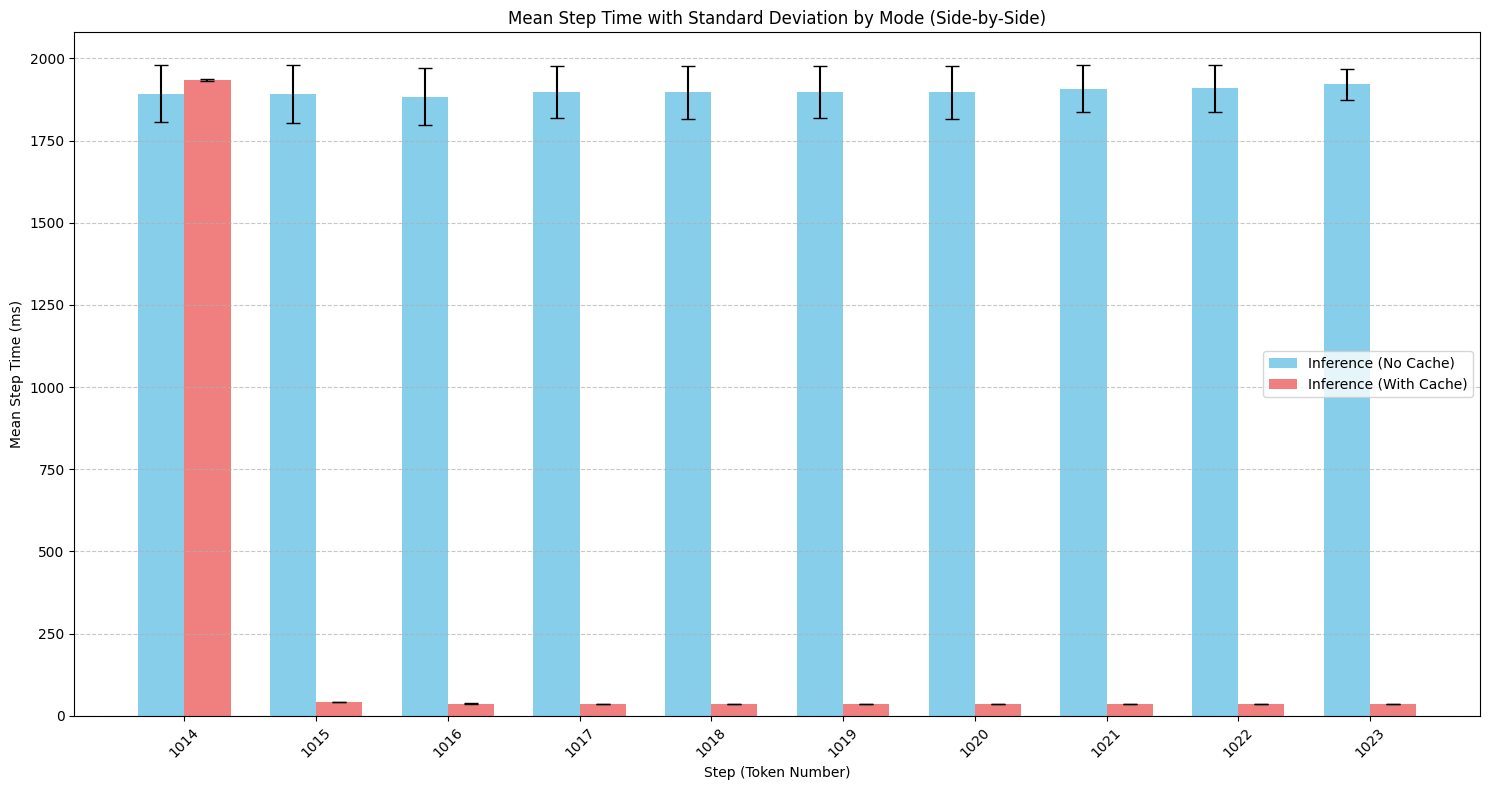

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data for plotting
plot_data = []

if 'inf_no_cache_times' in locals() and inf_no_cache_times:
    for token_num, times in inf_no_cache_times.items():
        if times and len(times) > 0:
            times_np = np.array(times)
            plot_data.append({
                'Step': token_num,
                'Mean': np.mean(times_np),
                'Std': np.std(times_np),
                'Mode': 'inf_no_cache'
            })

if 'inf_cache_times' in locals() and inf_cache_times:
    for token_num, times in inf_cache_times.items():
        if times and len(times) > 0:
            times_np = np.array(times)
            plot_data.append({
                'Step': token_num,
                'Mean': np.mean(times_np),
                'Std': np.std(times_np),
                'Mode': 'inf_cache'
            })

df_plot = pd.DataFrame(plot_data)

# Filter data for each mode
df_no_cache = df_plot[df_plot['Mode'] == 'inf_no_cache'].sort_values(by='Step')
df_cache = df_plot[df_plot['Mode'] == 'inf_cache'].sort_values(by='Step')

# Ensure both dataframes have the same steps and align
common_steps = sorted(list(set(df_no_cache['Step']).intersection(set(df_cache['Step']))))
df_no_cache = df_no_cache[df_no_cache['Step'].isin(common_steps)]
df_cache = df_cache[df_cache['Step'].isin(common_steps)]

# Get the x-axis positions
num_steps = len(common_steps)
bar_width = 0.35
r1 = np.arange(num_steps) # Positions for inf_no_cache bars
r2 = [x + bar_width for x in r1] # Positions for inf_cache bars

plt.figure(figsize=(15, 8))

# Plot inf_no_cache bars
plt.bar(
    r1,
    df_no_cache['Mean'],
    yerr=df_no_cache['Std'],
    width=bar_width,
    capsize=5,
    color='skyblue',
    label='Inference (No Cache)'
)

# Plot inf_cache bars
plt.bar(
    r2,
    df_cache['Mean'],
    yerr=df_cache['Std'],
    width=bar_width,
    capsize=5,
    color='lightcoral',
    label='Inference (With Cache)'
)

plt.title('Mean Step Time with Standard Deviation by Mode (Side-by-Side)')
plt.xlabel('Step (Token Number)')
plt.ylabel('Mean Step Time (ms)')
plt.xticks([r + bar_width/2 for r in r1], [str(s) for s in common_steps], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()